In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("real_estate_realistic_700k.csv")

print(df.shape)

df.head()

(700000, 10)


,lead_id,cp_code,agent_name,call_date,call_duration,status,project,location,customer_name,phone_number
0,1,CP007,C19,2024-12-06,10,Not Connected,Smart Residency,Navi Mumbai,Customer_1,9100000000
1,2,CP009,C15,2024-01-13,69,Connected,Luxury Heights,Navi Mumbai,Customer_2,9100000001
2,3,CP005,C1,2024-12-21,77,Connected,Green Valley,Thane,Customer_3,9100000002
3,4,CP018,C2,2024-05-02,100,Connected,Green Valley,Mumbai,Customer_4,9100000003
4,5,CP011,C7,2024-11-24,11,Not Connected,Luxury Heights,Mumbai,Customer_5,9100000004


In [3]:
print("Data Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Data Types
lead_id           int64
cp_code          object
agent_name       object
call_date        object
call_duration     int64
status           object
project          object
location         object
customer_name    object
phone_number      int64
dtype: object

Missing Values
lead_id          0
cp_code          0
agent_name       0
call_date        0
call_duration    0
status           0
project          0
location         0
customer_name    0
phone_number     0
dtype: int64

Duplicate Rows
0


In [4]:
df.describe()

,lead_id,call_duration,phone_number
count,700000.000000,700000.000000,7.000000e+05
mean,350000.500000,51.724190,9.100350e+09
std,202072.738554,71.327581,2.020727e+05
min,1.000000,5.000000,9.100000e+09
25%,175000.750000,13.000000,9.100175e+09
50%,350000.500000,22.000000,9.100350e+09
75%,525000.250000,74.000000,9.100525e+09
max,700000.000000,1200.000000,9.100700e+09


In [5]:
status_counts = df['status'].value_counts()

print(status_counts)

status
Not Connected    420000
Connected        243656
Interested        32900
Site Visit         2800
Booked              644
Name: count, dtype: int64


In [6]:
status_percent = (
    df['status'].value_counts()
    / len(df)
    * 100
).round(3)

print(status_percent)

status
Not Connected    60.000
Connected        34.808
Interested        4.700
Site Visit        0.400
Booked            0.092
Name: count, dtype: float64


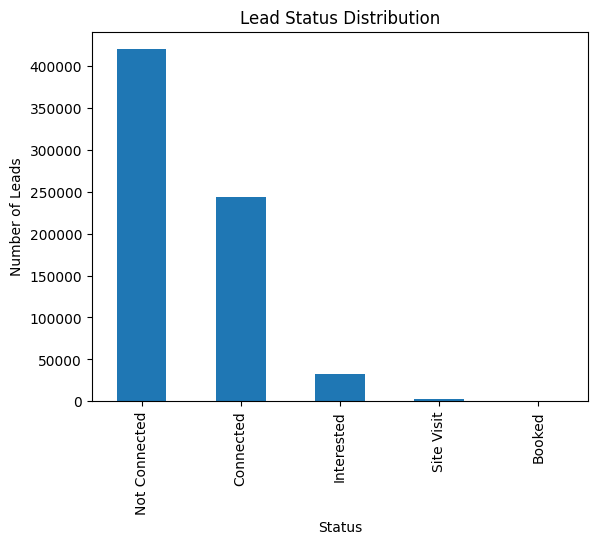

In [7]:
status_counts.plot(kind='bar')

plt.title('Lead Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Leads')

plt.show()

In [8]:
total_leads = len(df)

connected = len(df[df['status'] == 'Connected'])

interested = len(df[df['status'] == 'Interested'])

site_visit = len(df[df['status'] == 'Site Visit'])

booked = len(df[df['status'] == 'Booked'])

print(f"Total Leads: {total_leads}")
print(f"Connected Rate: {connected/total_leads*100:.3f}%")
print(f"Interested Rate: {interested/total_leads*100:.3f}%")
print(f"Site Visit Rate: {site_visit/total_leads*100:.3f}%")
print(f"Booking Rate: {booked/total_leads*100:.3f}%")

Total Leads: 700000
Connected Rate: 34.808%
Interested Rate: 4.700%
Site Visit Rate: 0.400%
Booking Rate: 0.092%


In [9]:
agent_performance = df['agent_name'].value_counts()

print(agent_performance)

agent_name
C14    69928
C7     63339
C1     56300
C2     48923
C19    48881
C9     42196
C3     41950
C4     35486
C15    35034
C6     34860
C5     34836
C10    27849
C8     27788
C13    27765
C20    21146
C12    20910
C18    20788
C11    14157
C16    14034
C17    13830
Name: count, dtype: int64


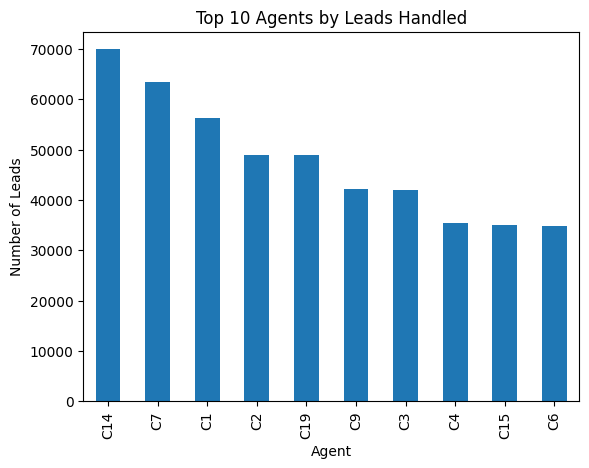

In [10]:
agent_performance.head(10).plot(kind='bar')

plt.title('Top 10 Agents by Leads Handled')
plt.xlabel('Agent')
plt.ylabel('Number of Leads')

plt.show()

In [11]:
bookings = df[df['status'] == 'Booked']

print(bookings.shape)

(644, 10)


In [12]:
best_agents = bookings['agent_name'].value_counts()

print(best_agents.head(10))

agent_name
C14    67
C7     59
C1     50
C19    47
C2     47
C6     40
C3     39
C9     36
C13    33
C4     30
Name: count, dtype: int64


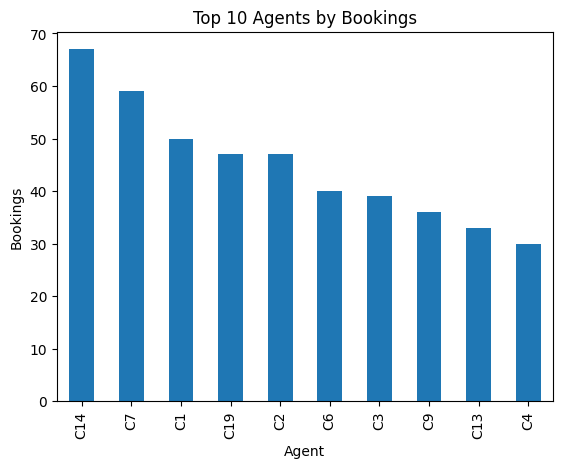

In [13]:
best_agents.head(10).plot(kind='bar')

plt.title('Top 10 Agents by Bookings')
plt.xlabel('Agent')
plt.ylabel('Bookings')

plt.show()

In [14]:
agent_summary = pd.crosstab(
    df['agent_name'],
    df['status']
)

agent_summary['Booking_Rate'] = (
    agent_summary['Booked']
    /
    agent_summary.sum(axis=1)
    * 100
)

agent_summary[['Booking_Rate']].sort_values(
    by='Booking_Rate',
    ascending=False
).head(10)

status,Booking_Rate
agent_name,
C13,0.118855
C6,0.114745
C16,0.114009
C17,0.108460
C8,0.104362
C19,0.096152
C2,0.096069
C14,0.095813
C7,0.093150


In [15]:
location_counts = df['location'].value_counts()

print(location_counts)

location
Mumbai         300617
Navi Mumbai    252154
Thane          147229
Name: count, dtype: int64


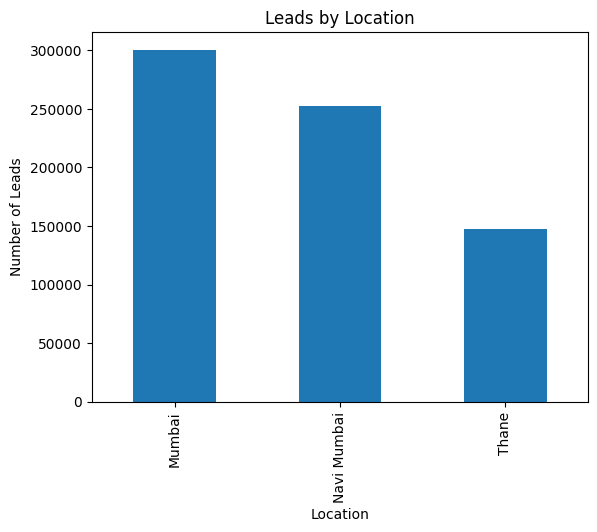

In [16]:
location_counts.plot(kind='bar')

plt.title('Leads by Location')
plt.xlabel('Location')
plt.ylabel('Number of Leads')

plt.show()

In [17]:
location_bookings = bookings['location'].value_counts()

print(location_bookings)

location
Mumbai         280
Navi Mumbai    247
Thane          117
Name: count, dtype: int64


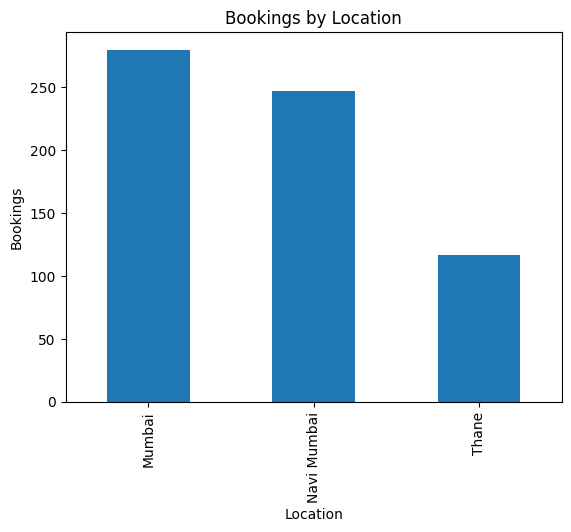

In [18]:
location_bookings.plot(kind='bar')

plt.title('Bookings by Location')
plt.xlabel('Location')
plt.ylabel('Bookings')

plt.show()

In [19]:
project_counts = df['project'].value_counts()

print(project_counts)

project
Green Valley       279816
Luxury Heights     245066
Smart Residency    175118
Name: count, dtype: int64


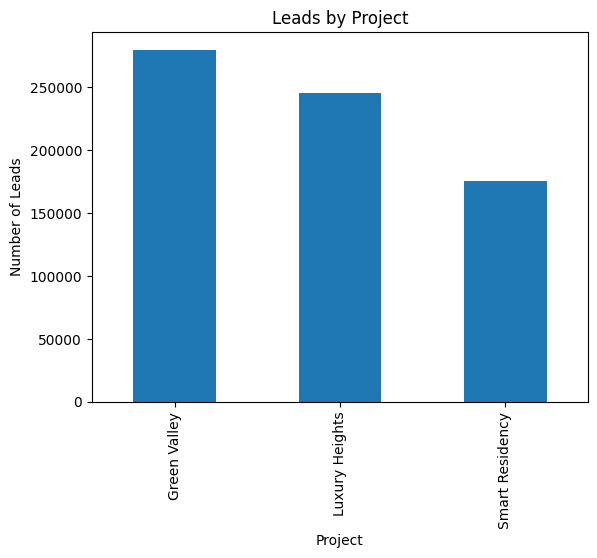

In [20]:
project_counts.plot(kind='bar')

plt.title('Leads by Project')
plt.xlabel('Project')
plt.ylabel('Number of Leads')

plt.show()

In [26]:
cp_leads = df['cp_code'].value_counts()

print(cp_leads.head(10))

cp_code
CP003    35301
CP001    35204
CP018    35190
CP010    35181
CP014    35162
CP012    35161
CP017    35135
CP006    35058
CP016    35051
CP004    35030
Name: count, dtype: int64


In [30]:
site_visits = df[df['status'] == 'Site Visit']

top_cp_site_visits = site_visits['cp_code'].value_counts()

print(top_cp_site_visits.head(10))

cp_code
CP009    169
CP015    162
CP013    160
CP011    154
CP018    152
CP001    150
CP010    150
CP005    141
CP006    141
CP012    140
Name: count, dtype: int64


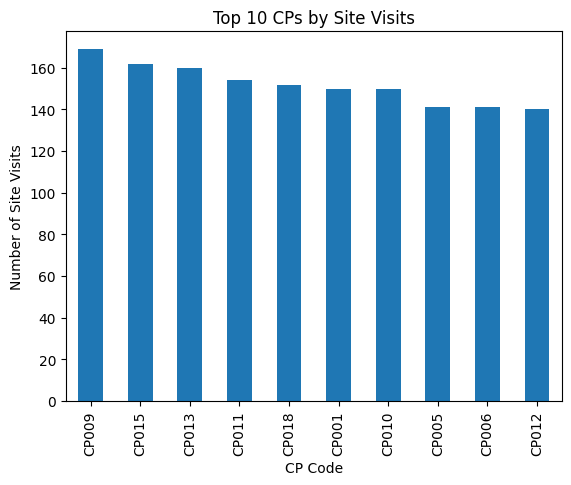

In [31]:
top_cp_site_visits.head(10).plot(kind='bar')

plt.title('Top 10 CPs by Site Visits')
plt.xlabel('CP Code')
plt.ylabel('Number of Site Visits')

plt.show()

In [27]:
cp_bookings = bookings['cp_code'].value_counts()

print(cp_bookings.head(10))

cp_code
CP012    42
CP011    39
CP005    38
CP001    38
CP004    36
CP018    36
CP016    35
CP008    35
CP007    33
CP015    33
Name: count, dtype: int64


In [28]:
cp_summary = pd.crosstab(
    df['cp_code'],
    df['status']
)

cp_summary['Booking_Rate'] = (
    cp_summary['Booked']
    /
    cp_summary.sum(axis=1)
    * 100
)

cp_summary[['Booking_Rate']].sort_values(
    by='Booking_Rate',
    ascending=False
).head(10)

status,Booking_Rate
cp_code,
CP012,0.119451
CP011,0.111796
CP005,0.108898
CP001,0.107942
CP004,0.102769
CP018,0.102302
CP008,0.100243
CP016,0.099854
CP015,0.094651


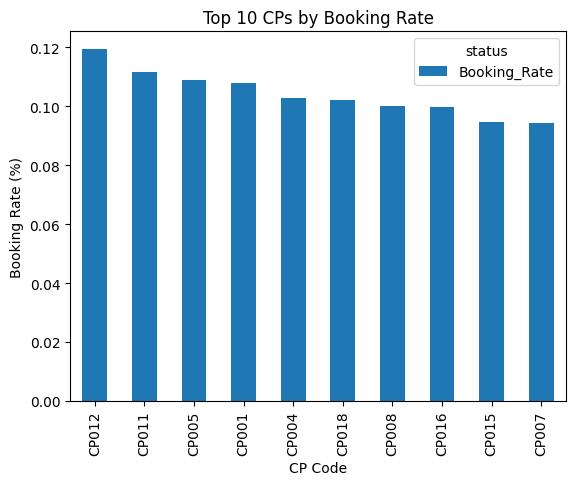

In [29]:
top_cp = cp_summary[['Booking_Rate']].sort_values(
    by='Booking_Rate',
    ascending=False
).head(10)

top_cp.plot(kind='bar')

plt.title('Top 10 CPs by Booking Rate')
plt.xlabel('CP Code')
plt.ylabel('Booking Rate (%)')

plt.show()

In [21]:
project_bookings = bookings['project'].value_counts()

print(project_bookings)

project
Green Valley       258
Luxury Heights     236
Smart Residency    150
Name: count, dtype: int64


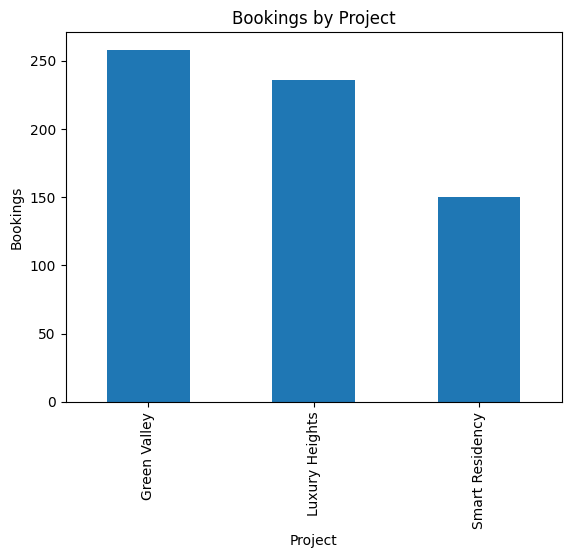

In [22]:
project_bookings.plot(kind='bar')

plt.title('Bookings by Project')
plt.xlabel('Project')
plt.ylabel('Bookings')

plt.show()

In [23]:
duration_status = (
    df.groupby('status')['call_duration']
    .mean()
    .sort_values()
)

print(duration_status)

status
Not Connected      15.011481
Connected          79.991197
Interested        250.181216
Site Visit        548.419286
Booked           1001.925466
Name: call_duration, dtype: float64


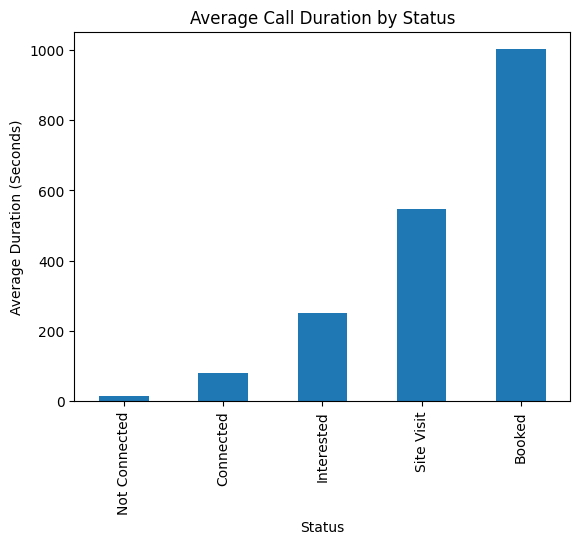

In [24]:
duration_status.plot(kind='bar')

plt.title('Average Call Duration by Status')
plt.xlabel('Status')
plt.ylabel('Average Duration (Seconds)')

plt.show()

In [32]:
print("""
BUSINESS INSIGHTS

1. A significant proportion of leads remained uncontacted, highlighting challenges in initial customer outreach.

2. Only 4.7% of total leads progressed to the Interested stage, indicating a substantial drop-off in the conversion funnel.

3. Site visits accounted for just 0.4% of total leads, making this a critical bottleneck in the sales process.

4. The overall booking conversion rate was only 0.092%, emphasizing the highly competitive nature of real-estate lead conversion.

5. Top-performing agents consistently achieved higher booking rates than their peers, demonstrating the impact of effective lead handling.

6. Average call duration increased as leads moved deeper into the funnel, suggesting stronger customer engagement at advanced stages.

7. Location-wise analysis revealed differences in booking performance, indicating varying market potential across regions.

8. Project-wise analysis showed variations in customer interest and booking outcomes, helping identify better-performing developments.

9. Certain Channel Partners (CPs) generated significantly more site visits and bookings, indicating higher lead quality and stronger conversion potential.

10. CP performance analysis highlighted opportunities to prioritize high-converting partners and optimize marketing investments.
""")


BUSINESS INSIGHTS

1. A significant proportion of leads remained uncontacted, highlighting challenges in initial customer outreach.

2. Only 4.7% of total leads progressed to the Interested stage, indicating a substantial drop-off in the conversion funnel.

3. Site visits accounted for just 0.4% of total leads, making this a critical bottleneck in the sales process.

4. The overall booking conversion rate was only 0.092%, emphasizing the highly competitive nature of real-estate lead conversion.

5. Top-performing agents consistently achieved higher booking rates than their peers, demonstrating the impact of effective lead handling.

6. Average call duration increased as leads moved deeper into the funnel, suggesting stronger customer engagement at advanced stages.

7. Location-wise analysis revealed differences in booking performance, indicating varying market potential across regions.

8. Project-wise analysis showed variations in customer interest and booking outcomes, helping ident

In [1]:
import os
print(os.getcwd())

C:\Users\amanp
